# Environment-driven growth on the NCA manifold

A single seed cell grows into a plant whose developmental stage is decided by **two
external signals**, not by a latent index:

| signal | shape | mechanism | controls |
|---|---|---|---|
| nutrient $n(t)$ | global scalar in $[0,1]$, time-varying | environment encoder: $\kappa = P(D(Z(n)))$ | **what** grows — the developmental stage |
| chemical $\mathrm{chem}(x,y)$ | spatial field in $[0,1]$ | hard gate on the whole per-cell transition | **whether / where** growth happens at all |

The nutrient reaches every channel through the *generated weights* — the whole update
rule is a function of it, exactly the manifold mechanism from `nca_manifold.ipynb`, with
the free latents replaced by an encoder $Z(n)$. The chemical gates the entire state
transition of every channel identically: `chem = 0` means a cell is **exactly frozen**,
by construction. It is deliberately *not* in the perception vector — it is physics, not
an input the rule can learn to ignore.

Four developmental stages, one nutrient level each: seed blob (0.10), sprout (0.40),
leafy plant (0.70), flowering plant (1.00). All grow from the identical single-cell seed.

### Three dynamics lessons this notebook encodes (found the hard way)

1. **The chemical must gate death too.** The alive-mask kill is not idempotent —
   masking lowers neighbourhood alpha, which can kill further cells — so gating only the
   update `ds` lets a `chem = 0` cell still change on the next step.
2. **Nutrient jitter must partition $[0,1]$ with no gaps.** Every value a slow ramp
   visits must be trained; untrained gaps between stage basins grew duplicate flower heads.
3. **Slow ramps need their own training episodes, in both directions.** Error accrues
   *per step* spent under in-motion interpolated rules, so short glides do not cover a
   480-step ramp. Truncated BPTT on the real ramp does. (A persistence "hold" segment
   made things *worse* — it taught the rules to preserve ghost residue.)

The script version of this notebook is `env_growth.py` (same code, CLI, exits non-zero
if verification fails). Design doc:
`docs/superpowers/specs/2026-08-26-env-driven-growth-design.md`.

## Setup

In [1]:
import copy
import math
import os
import time
from dataclasses import asdict, dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image as IPyImage
from IPython.display import clear_output, display
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## recessive chart furniture; the data should be the only thing with weight
INK, INK_MUTED, GRIDLINE, SERIES = "#3f3f46", "#a1a1aa", "#e4e4e7", "#2f6f9f"
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10, "font.size": 9})

print(f"torch {torch.__version__} | device {DEVICE}")

torch 2.11.0+cu126 | device cuda


## Configuration

Every constant lives here. The one invariant to respect if you change the stage levels:
**`env_jitter` must make the stage basins partition $[0,1]$ exactly** — with levels at
`0.1 / 0.4 / 0.7 / 1.0`, a jitter of `0.15` gives basins `[0,.25][.25,.55][.55,.85][.85,1]`
with no untrained gap for a slow nutrient ramp to visit.

In [2]:
@dataclass
class Config:
    ## --- cell state ------------------------------------------------------
    channels: int = 16              ## 4 visible (RGBA) + 12 hidden
    grid: int = 40
    alive_threshold: float = 0.1
    fire_rate: float = 0.5          ## stochastic per-cell update, train AND eval

    ## --- update rule -----------------------------------------------------
    hidden: int = 128
    leak_init: float = 0.1          ## Euler timestep

    ## --- the manifold ----------------------------------------------------
    latent_dim: int = 8
    dna_hidden: int = 64
    env_hidden: int = 64            ## width of the environment encoder Z(n)

    ## --- training --------------------------------------------------------
    epochs: int = 6000
    lr: float = 2e-3
    scalar_lr: float = 1e-4         ## scalars bypass gradient normalisation
    seg1_min: int = 48              ## seed -> stage rollout length
    seg1_max: int = 64
    seg2_min: int = 32              ## post-switch rollout length
    seg2_max: int = 48
    env_jitter: float = 0.15        ## nutrient noise around each stage level. 0.15 makes
                                    ## the basins partition [0,1] EXACTLY -- see above
    state_noise: float = 0.05       ## perturbation before segment 2 -> rules clean up
    slow_ramp_prob: float = 0.33    ## fraction of epochs trained on true slow-ramp states
    seed: int = 0
    log_every: int = 100
    eval_every: int = 50            ## fixed eval for best-checkpoint tracking

    ## --- io --------------------------------------------------------------
    out_dir: str = "outputs"
    ckpt_name: str = "env_growth.pth"

    @property
    def perception(self) -> int:
        return 3 * self.channels    ## identity + sobel_x + sobel_y


CFG = Config()
os.makedirs(CFG.out_dir, exist_ok=True)
CFG

Config(channels=16, grid=40, alive_threshold=0.1, fire_rate=0.5, hidden=128, leak_init=0.1, latent_dim=8, dna_hidden=64, env_hidden=64, epochs=6000, lr=0.002, scalar_lr=0.0001, seg1_min=48, seg1_max=64, seg2_min=32, seg2_max=48, env_jitter=0.15, state_noise=0.05, slow_ramp_prob=0.33, seed=0, log_every=100, eval_every=50, out_dir='outputs', ckpt_name='env_growth.pth')

## Rendering helpers

RGBA states are composited over a checkerboard so transparency is distinguishable from
black. `composite` optionally tints the background pale yellow where the chemical field
is present, so the field itself is visible in the chemical demos.

In [3]:
def _checkerboard(h, w, tile=2):
    yy, xx = np.mgrid[0:h, 0:w]
    return np.where(((yy // tile) + (xx // tile)) % 2 == 0, 0.74, 0.82)


def upscale(a, s=5):
    """Nearest-neighbour zoom. A 40x40 organism is unreadable at native size."""
    return np.kron(a, np.ones((s, s, 1))) if a.ndim == 3 else np.kron(a, np.ones((s, s)))


def composite(state_chw, chem=None):
    """(C,H,W) tensor -> (H,W,3) array. RGBA over a checkerboard; chem (H,W), if given,
    tints the background where the chemical is present."""
    rgba = state_chw[0:4].detach().clamp(0, 1).cpu().numpy()
    rgb, a = rgba[0:3].transpose(1, 2, 0), rgba[3][..., None]
    bg = _checkerboard(*rgb.shape[:2])[..., None] * np.ones(3)
    if chem is not None:
        c = chem.detach().clamp(0, 1).cpu().numpy().reshape(*rgb.shape[:2], 1)
        tint = np.array([1.00, 0.96, 0.72])
        bg = np.clip(bg * (1 - 0.5 * c) + tint * 0.5 * c * bg.mean(axis=2, keepdims=True) * 1.25, 0, 1)
    return np.clip(rgb * a + bg * (1 - a), 0, 1)


def frame_with_bar(img, level, label, bar_h=10):
    """Append a signal-level bar below an (H,W,3) image: green = nutrient, gold = chem."""
    h, w, _ = img.shape
    bar = np.full((bar_h + 4, w, 3), 0.92)
    fill = int(round(level * (w - 4)))
    bar[2:-2, 2:2 + fill] = np.array([0.30, 0.62, 0.32]) if label == "nutrient" \
        else np.array([0.85, 0.75, 0.25])
    return np.concatenate([img, bar], axis=0)


def save_gif(frames_rgb, path, duration=70):
    imgs = [Image.fromarray((f * 255).astype(np.uint8)) for f in frames_rgb]
    imgs[0].save(path, save_all=True, append_images=imgs[1:], duration=duration, loop=0)
    print(f"saved {path} ({len(imgs)} frames)")
    return path


def tile_figure(images, ncols, titles=None, row_labels=None, suptitle=None,
                scale=5, tile_in=1.7, chems=None, path=None):
    """Lay out a list of (C,H,W) states row-major. `chems` is an optional parallel list
    of (H,W) chemical fields for background tinting."""
    n = len(images)
    nrows = math.ceil(n / ncols)
    fig, ax = plt.subplots(nrows, ncols, squeeze=False,
                           figsize=(tile_in * ncols, tile_in * nrows + (0.8 if suptitle else 0)))
    for i in range(nrows * ncols):
        r, c = divmod(i, ncols)
        a = ax[r][c]
        a.set_xticks([])
        a.set_yticks([])
        if i >= n:
            a.axis("off")
            continue
        chem = chems[i] if chems is not None else None
        a.imshow(upscale(composite(images[i], chem), scale), interpolation="nearest")
        if titles and titles[i]:
            a.set_title(titles[i], fontsize=8, color=INK)
        if row_labels and c == 0 and r < len(row_labels):
            a.set_ylabel(row_labels[r], fontsize=8, color=INK)
    if suptitle:
        fig.suptitle(suptitle, fontsize=10, color=INK)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=110, bbox_inches="tight")
        print(f"saved {path}")
    plt.show()
    return fig

## Targets — four developmental stages, one nutrient level each

The stages are **nested** (each contains the previous) and share the anchor point where
the seed cell is planted, so development is monotone growth. To use different stages,
edit `plant_targets` — and keep the `env_jitter` partition invariant if you move the
nutrient levels.

K = 4 stages at nutrient levels [0.10000000149011612, 0.4000000059604645, 0.699999988079071, 1.0]


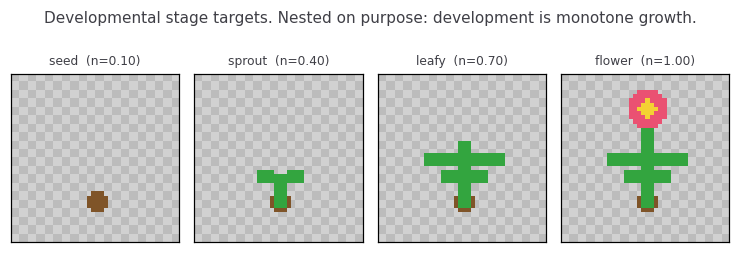

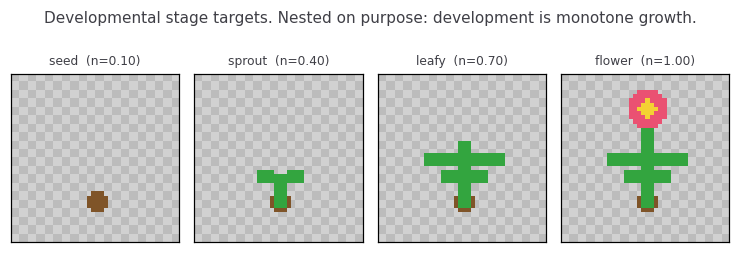

In [4]:
GREEN = (0.20, 0.65, 0.25)
BROWN = (0.50, 0.33, 0.16)
PINK = (0.92, 0.32, 0.45)
YELLOW = (0.96, 0.82, 0.20)


def plant_targets(cfg=CFG):
    """(4, 4, grid, grid) RGBA targets + names + nutrient levels."""
    g = cfg.grid
    yy, xx = torch.meshgrid(torch.arange(g, dtype=torch.float32),
                            torch.arange(g, dtype=torch.float32), indexing="ij")
    ground, cx = 31.0, g / 2.0

    def ellipse(cy_, cx_, ry, rx):
        return ((yy - cy_) / ry) ** 2 + ((xx - cx_) / rx) ** 2 <= 1.0

    def stem(top):
        return (yy >= top) & (yy <= ground) & ((xx - cx).abs() <= 1.0)

    seed_blob = [(ellipse(ground - 1, cx, 2.2, 2.6), BROWN)]
    mini_leaves = [(ellipse(24.0, cx - 3.2, 1.5, 2.6), GREEN),
                   (ellipse(24.0, cx + 3.2, 1.5, 2.6), GREEN)]
    big_leaves = [(ellipse(20.0, cx - 5.5, 2.0, 4.2), GREEN),
                  (ellipse(20.0, cx + 5.5, 2.0, 4.2), GREEN)]
    flower = [(ellipse(8.0, cx, 4.6, 4.6), PINK),
              (ellipse(8.0, cx, 2.0, 2.0), YELLOW)]

    stages = [
        ("seed", 0.10, seed_blob),
        ("sprout", 0.40, seed_blob + [(stem(24.0), GREEN)] + mini_leaves),
        ("leafy", 0.70, seed_blob + [(stem(16.0), GREEN)] + mini_leaves + big_leaves),
        ("flower", 1.00, seed_blob + [(stem(12.0), GREEN)] + mini_leaves + big_leaves + flower),
    ]

    out = torch.zeros(len(stages), 4, g, g)
    names, envs = [], []
    for i, (name, n, layers) in enumerate(stages):
        for mask, rgb in layers:                        ## later layers paint over earlier
            for c in range(3):
                out[i, c] = torch.where(mask, torch.tensor(rgb[c]), out[i, c])
            out[i, 3] = torch.maximum(out[i, 3], mask.float())
        names.append(name)
        envs.append(n)
    return out, names, torch.tensor(envs)


TARGETS, NAMES, ENVS = plant_targets(CFG)
TARGETS, ENVS = TARGETS.to(DEVICE), ENVS.to(DEVICE)
K = TARGETS.shape[0]
print(f"K = {K} stages at nutrient levels {ENVS.tolist()}")

tile_figure([TARGETS[i] for i in range(K)], ncols=K,
            titles=[f"{n}  (n={e:.2f})" for n, e in zip(NAMES, ENVS.tolist())],
            suptitle="Developmental stage targets. Nested on purpose: development is monotone growth.")

## The model

`EnvNCA` is `ManifoldNCA` from `nca_manifold.ipynb` with two changes:

1. The free per-target latents are replaced by **`env_encoder`** — the latent is
   *computed from the environment*, so the nutrient selects the point on the manifold.
   Everything downstream (DNA decoder, zero-init predictor, residual-on-base-rule
   weights, replicate padding, fire mask shared across channels and active in eval) is
   carried over unchanged.
2. `forward` takes a chemical field and gates the **entire** per-cell transition with
   it: `state' = state + (nca_step(state) - state) * chem`. Growth *and* death — the
   alive-mask kill is not idempotent, so gating only `ds` would let a `chem = 0` cell
   still die on the next step.

`simulate` is the eval loop for **time-varying** environments: weights are regenerated
whenever the nutrient changes, which is what makes a per-step nutrient ramp possible.

In [5]:
class EnvNCA(nn.Module):
    """A manifold NCA whose latent is COMPUTED FROM THE ENVIRONMENT.

    kappa(n) = P(D(Z(n))): the nutrient level n is encoded to a latent, the latent is
    decoded to the update net's weights (residual on a learned base rule, predictor
    zero-init). forward() additionally takes a chemical field that hard-gates the
    whole state transition.
    """

    def __init__(self, cfg=CFG):
        super().__init__()
        self.cfg = cfg

        self.env_encoder = nn.Sequential(
            nn.Linear(1, cfg.env_hidden), nn.ReLU(),
            nn.Linear(cfg.env_hidden, cfg.latent_dim))

        self.n_generated = cfg.hidden * cfg.perception + cfg.hidden + cfg.channels * cfg.hidden
        self.dna_decoder = nn.Sequential(nn.Linear(cfg.latent_dim, cfg.dna_hidden), nn.ReLU())
        self.predictor = nn.Linear(cfg.dna_hidden, self.n_generated)
        nn.init.zeros_(self.predictor.weight)          ## start as a zero residual: every
        nn.init.zeros_(self.predictor.bias)            ## environment decodes to the base rule

        self.base_w1 = nn.Parameter(torch.randn(cfg.hidden, cfg.perception) * 0.001)
        self.base_b1 = nn.Parameter(torch.zeros(cfg.hidden))
        self.base_w2 = nn.Parameter(torch.zeros(cfg.channels, cfg.hidden))

        self.log_leak = nn.Parameter(torch.tensor(math.log(cfg.leak_init)))

        sx = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]])
        sy = torch.tensor([[1.0, 2.0, 1.0], [0.0, 0.0, 0.0], [-1.0, -2.0, -1.0]])
        self.register_buffer("kx", sx.view(1, 1, 3, 3).repeat(cfg.channels, 1, 1, 1))
        self.register_buffer("ky", sy.view(1, 1, 3, 3).repeat(cfg.channels, 1, 1, 1))

    def weights_for(self, n):
        """(B,) nutrient levels -> the update net's (w1, b1, w2), batched over B."""
        cfg = self.cfg
        z = self.env_encoder(n.view(-1, 1))
        theta = self.predictor(self.dna_decoder(z))
        b, i = z.shape[0], 0
        k = cfg.hidden * cfg.perception
        w1 = self.base_w1 + theta[:, i:i + k].view(b, cfg.hidden, cfg.perception)
        i += k
        b1 = self.base_b1 + theta[:, i:i + cfg.hidden]
        i += cfg.hidden
        w2 = self.base_w2 + theta[:, i:].view(b, cfg.channels, cfg.hidden)
        return w1, b1, w2

    def perceive(self, state):
        p = F.pad(state, (1, 1, 1, 1), mode="replicate")   ## no-flux, not a torus
        gx = F.conv2d(p, self.kx, groups=self.cfg.channels)
        gy = F.conv2d(p, self.ky, groups=self.cfg.channels)
        return torch.cat([state, gx, gy], dim=1)

    def alive_mask(self, state):
        return F.max_pool2d(state[:, 3:4], 3, stride=1, padding=1) > self.cfg.alive_threshold

    def forward(self, state, weights, chem=None):
        """One step. chem is (B,1,H,W) in [0,1] or None (== 1 everywhere).

        chem gates the ENTIRE per-cell state transition -- growth AND death -- because
        both are state changes the chemical fuels. chem == 0 therefore freezes a cell
        exactly, by construction, and the rule cannot ignore it.
        """
        w1, b1, w2 = weights
        pre = self.alive_mask(state)

        p = self.perceive(state)
        a = torch.einsum("bop,bpij->boij", w1, p) + b1[:, :, None, None]
        ds = torch.einsum("bcv,bvij->bcij", w2, F.relu(a))

        m = (torch.rand_like(ds[:, :1]) <= self.cfg.fire_rate).to(ds.dtype)
        out = state + self.log_leak.exp() * ds * m
        new = out * (pre & self.alive_mask(out)).to(out.dtype)

        if chem is None:
            return new
        return state + (new - state) * chem


def new_seed(n, cfg=CFG, device=DEVICE):
    """A single living cell where the plant is anchored -- identical for every sample."""
    s = torch.zeros(n, cfg.channels, cfg.grid, cfg.grid, device=device)
    s[:, 3, 30, cfg.grid // 2] = 1.0
    return s


def rollout(model, state, weights, steps, chem=None):
    for _ in range(steps):
        state = model(state, weights, chem)
    return state


def rollout_moving(model, state, n_from, n_to, steps, frac=0.6, chem=None):
    """Rollout under an environment IN MOTION: n glides linearly from n_from to n_to
    over the first `frac` of the segment, then holds at n_to. Weights are regenerated
    every step, exactly like a nutrient ramp at eval."""
    ramp_steps = max(1, int(steps * frac))
    for i in range(steps):
        t = min(1.0, (i + 1) / ramp_steps)
        state = model(state, model.weights_for(n_from + (n_to - n_from) * t), chem)
    return state


@torch.no_grad()
def simulate(model, env_fn, steps, chem_fn=None, state=None, record_every=1, seed=0):
    """Eval rollout under a TIME-VARYING environment.

    env_fn(t) -> nutrient level; weights are regenerated whenever it changes.
    chem_fn(t) -> chemical field (1,1,H,W) or None. Reseeds the global RNG.
    """
    cfg = model.cfg
    torch.manual_seed(seed)
    if state is None:
        state = new_seed(1, cfg, next(model.parameters()).device)
    frames, env_trace = [state.clone()], [float(env_fn(0))]
    cur_n, weights = None, None
    for t in range(steps):
        n = float(env_fn(t))
        if n != cur_n:
            weights = model.weights_for(torch.tensor([n], device=state.device))
            cur_n = n
        chem = chem_fn(t) if chem_fn is not None else None
        state = model(state, weights, chem)
        if (t + 1) % record_every == 0:
            frames.append(state.clone())
            env_trace.append(n)
    return state, frames, env_trace


@torch.no_grad()
def grow(model, n_values, steps, chem=None, state=None, seed=0):
    """Fixed-environment eval rollout, one row per nutrient level."""
    torch.manual_seed(seed)
    if state is None:
        state = new_seed(n_values.shape[0], model.cfg, n_values.device)
    return rollout(model, state, model.weights_for(n_values), steps, chem)


torch.manual_seed(CFG.seed)
model = EnvNCA(CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} parameters total")
print(f"the predictor emits {model.n_generated:,} update-net weights per environment")

550,345 parameters total
the predictor emits 8,320 update-net weights per environment


## Sanity checks

Run **before** spending any training time. The gradient checks carry over from
`nca_manifold.ipynb` (the predictor is zero-initialised on purpose, so the environment
path is probed on a throwaway copy with a small non-zero predictor). New here: the
chem gate must freeze a cell **exactly** — a max-abs-diff of literally `0.0`, not small.

In [6]:
def sanity_check(model, targets, envs):
    cfg = model.cfg
    dev = next(model.parameters()).device
    k = envs.shape[0]

    w1, b1, w2 = model.weights_for(envs)
    assert w1.shape == (k, cfg.hidden, cfg.perception), w1.shape
    assert b1.shape == (k, cfg.hidden), b1.shape
    assert w2.shape == (k, cfg.channels, cfg.hidden), w2.shape

    state = new_seed(k, cfg, dev)
    out = model(state, (w1, b1, w2))
    assert out.shape == state.shape
    assert torch.isfinite(out).all(), "non-finite values after a single step"

    ## chem gate: zero chemical must freeze the state EXACTLY
    chem0 = torch.zeros(k, 1, cfg.grid, cfg.grid, device=dev)
    frozen = model(state, (w1, b1, w2), chem0)
    assert (frozen - state).abs().max().item() == 0.0, "chem=0 did not freeze the state"

    ## gradient must reach the predictor at init (the thing that moves it off zero)
    final = rollout(model, new_seed(k, cfg, dev), (w1, b1, w2), 8)
    loss = F.mse_loss(final[:, 0:4], targets)
    g_pred = torch.autograd.grad(loss, model.predictor.weight)[0].norm().item()
    assert math.isfinite(g_pred) and g_pred > 0, f"grad->predictor {g_pred}"

    ## the env-encoder path is probed on a copy with a small non-zero predictor:
    ## at init theta = P(D(Z(n))) = 0 for every n, so its gradient is legitimately zero.
    probe = copy.deepcopy(model)
    nn.init.normal_(probe.predictor.weight, std=1e-3)
    p_final = rollout(probe, new_seed(k, cfg, dev), probe.weights_for(envs), 8)
    g_env = torch.autograd.grad(F.mse_loss(p_final[:, 0:4], targets),
                                probe.env_encoder[0].weight)[0].norm().item()
    assert math.isfinite(g_env) and g_env > 0, f"grad->env_encoder {g_env}"

    print(f"  weight shapes        w1 {tuple(w1.shape)}  b1 {tuple(b1.shape)}  w2 {tuple(w2.shape)}")
    print(f"  chem = 0             freezes the state exactly (max|delta| = 0.0)")
    print(f"  grad -> predictor    {g_pred:.3e}   (must be > 0 at init)")
    print(f"  grad -> env encoder  {g_env:.3e}   (probe copy, must be > 0)")
    print("all checks passed")


sanity_check(model, TARGETS, ENVS)

  weight shapes        w1 (4, 128, 48)  b1 (4, 128)  w2 (4, 16, 128)
  chem = 0             freezes the state exactly (max|delta| = 0.0)
  grad -> predictor    1.318e-05   (must be > 0 at init)
  grad -> env encoder  2.062e-08   (probe copy, must be > 0)
all checks passed


## Checkpoint save / load

In [7]:
def save_checkpoint(model, names, envs, cfg, path=None):
    path = path or os.path.join(cfg.out_dir, cfg.ckpt_name)
    torch.save({"state_dict": model.state_dict(), "names": names,
                "envs": envs.cpu(), "config": asdict(cfg)}, path)
    print(f"saved {path}")
    return path


def load_checkpoint(path, device=DEVICE):
    ck = torch.load(path, map_location=device, weights_only=False)
    cfg = Config(**ck["config"])
    m = EnvNCA(cfg).to(device)
    m.load_state_dict(ck["state_dict"])
    m.eval()
    return m, ck["names"], ck["envs"].to(device), cfg

## Training — environment change is trained explicitly, not hoped for

Two episode types, mixed per epoch (batch of 8 = 4 identity + 4 transition samples):

**Two-segment episodes (~2/3 of epochs).** Segment 1: seed → rollout under jittered
$n_a$ → MSE vs target $a$. Segment 2, from the *detached* segment-1 state (pool-style,
keeps memory at one-segment cost): the env changes to jittered $n_b$ — identity samples
keep $b = a$ (persistence), transitions pick random $b \ne a$, both directions — then
MSE vs target $b$. Half the switches are instant; half **glide** with weights
regenerated every step. Half the segment-2 start states are perturbed with noise so
rules learn to clean up.

**Slow-ramp episodes (~1/3 of epochs, truncated BPTT).** End-state error on a slow
nutrient ramp scales with ramp *duration* — 0.002/step ramps sit for many steps under
in-motion rules that short glides never visit. So the actual slow ramp (ascending or
descending, random virtual duration 300–700 steps) is rolled from seed under `no_grad`
to a random depth (zero memory cost), and only the continuation is trained: a few more
ramp steps, a hold at the nearest stage level, MSE vs that stage's target.

Best-checkpoint tracking uses a **fixed periodic eval** (stage growth + an ascending
and a descending 240-step ramp) because the two episode types have incomparable
training losses. The left plot shows both training losses; the right shows the fixed
eval that actually selects the checkpoint.

Carried over from `nca_manifold.ipynb`: per-parameter gradient normalisation with
scalars in a separate low-LR group, cosine LR schedule, random rollout lengths.
`chem = 1` everywhere during training — the gate is exact physics and needs no training.

In [8]:
def _slow_ramp_episode(model, targets, envs, cfg):
    """Truncated BPTT on a slow nutrient ramp -- the eval distribution itself."""
    dev = targets.device
    k = envs.shape[0]
    b = 2 * k
    levels = envs.tolist()

    tv = int(torch.randint(300, 701, (1,)).item())      ## virtual ramp duration
    ramp_len = max(1, int(0.85 * tv))
    T = int(torch.randint(0, tv - 60, (1,)).item())     ## truncation depth
    descending = torch.rand(1).item() < 0.5             ## both directions, or downward
                                                        ## transitions keep stable ghosts

    def rampn(t):
        if descending:
            return max(0.10, 1.00 - 0.90 * t / ramp_len)
        return min(1.0, 0.10 + 0.90 * t / ramp_len)

    state = new_seed(b, cfg, dev)
    with torch.no_grad():
        for t in range(T):
            n = torch.full((b,), rampn(t), device=dev)
            state = model(state, model.weights_for(n))

    g = int(torch.randint(8, 17, (1,)).item())          ## trained ramp continuation
    for t in range(T, T + g):
        n = torch.full((b,), rampn(t), device=dev)
        state = model(state, model.weights_for(n))

    n_end = rampn(T + g)
    stage = min(range(k), key=lambda i: abs(levels[i] - n_end))
    h = int(torch.randint(24, 41, (1,)).item())         ## hold at the snapped stage
    n_hold = envs[stage:stage + 1].expand(b)
    state = rollout(model, state, model.weights_for(n_hold), h)
    return F.mse_loss(state[:, 0:4], targets[stage].unsqueeze(0).expand(b, -1, -1, -1))


@torch.no_grad()
def _fixed_eval(model, targets, envs, cfg):
    """Deterministic eval for best-checkpoint tracking: stage growth + an ascending and
    a descending ramp. Saves and restores the global RNG so training is untouched."""
    cpu_state = torch.get_rng_state()
    cuda_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    try:
        final = grow(model, envs, cfg.seg1_max, seed=2)
        score = F.mse_loss(final[:, 0:4], targets).item()
        ramp = lambda t: min(1.0, 0.10 + 0.90 * t / (240 * 0.85))
        end, _, _ = simulate(model, ramp, 240, seed=5)
        score += F.mse_loss(end[:, 0:4], targets[-1:]).item()
        def down(t):
            if t < 100:
                return 1.00
            return max(0.40, round(1.00 - 0.60 * (t - 100) / 60, 3))
        end, _, _ = simulate(model, down, 260, seed=8)
        score += F.mse_loss(end[:, 0:4], targets[1:2]).item()
    finally:
        torch.set_rng_state(cpu_state)
        if cuda_states is not None:
            torch.cuda.set_rng_state_all(cuda_states)
    return score


def _training_plot(history, evals, epoch, best, elapsed):
    clear_output(wait=True)
    fig, (ax_l, ax_e) = plt.subplots(1, 2, figsize=(11, 3.4))
    ep = [h[0] for h in history]
    ax_l.plot(ep, [h[1] for h in history], color=SERIES, linewidth=1.1,
              label="grow (seed -> stage)")
    ax_l.plot(ep, [h[2] for h in history], color="#c2703d", linewidth=1.1, alpha=0.8,
              label="switch / slow ramp")
    ax_l.set_yscale("log")
    ax_l.legend(frameon=False, fontsize=8)
    ax_l.set_xlabel("epoch")
    ax_l.set_ylabel("MSE, log scale")
    ax_l.set_title(f"epoch {epoch}    {elapsed:.0f}s", loc="left", color=INK)
    if evals:
        ax_e.plot([e[0] for e in evals], [e[1] for e in evals], color=SERIES, linewidth=2)
        ax_e.set_yscale("log")
    ax_e.set_xlabel("epoch")
    ax_e.set_ylabel("fixed eval, log scale")
    ax_e.set_title(f"best {best:.6f}  (checkpoint criterion)", loc="left", color=INK)
    for ax in (ax_l, ax_e):
        ax.grid(True, color=GRIDLINE, linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_color(GRIDLINE)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
    fig.tight_layout()
    plt.show()


def train(model, targets, envs, cfg=None, live=True):
    cfg = cfg or model.cfg
    dev = targets.device
    k = envs.shape[0]

    ## scalars must NOT go through per-parameter gradient normalisation
    vec = [p for p in model.parameters() if p.numel() > 1]
    sca = [p for p in model.parameters() if p.numel() == 1]
    opt = torch.optim.Adam([{"params": vec, "lr": cfg.lr},
                            {"params": sca, "lr": cfg.scalar_lr}])

    history, evals = [], []
    best, best_state = float("inf"), copy.deepcopy(model.state_dict())
    t0 = time.time()

    for epoch in range(cfg.epochs):
        frac = epoch / max(cfg.epochs - 1, 1)
        opt.param_groups[0]["lr"] = cfg.lr * (0.05 + 0.95 * 0.5 * (1 + math.cos(math.pi * frac)))

        ident = torch.arange(k, device=dev)
        a_tr = torch.randint(0, k, (k,), device=dev)
        shift = torch.randint(1, k, (k,), device=dev)
        b_tr = (a_tr + shift) % k
        a_idx = torch.cat([ident, a_tr])               ## (2K,) segment-1 stages
        b_idx = torch.cat([ident, b_tr])               ## (2K,) segment-2 stages

        def jitter(n):
            j = (torch.rand_like(n) - 0.5) * 2 * cfg.env_jitter
            return (n + j).clamp(0.0, 1.0)

        opt.zero_grad()

        if torch.rand(1).item() < cfg.slow_ramp_prob:
            ## slow-ramp episode: train from true mid-ramp states (truncated BPTT)
            loss_r = _slow_ramp_episode(model, targets, envs, cfg)
            loss_r.backward()
            l1, l2 = float("nan"), loss_r.item()
        else:
            ## segment 1: seed -> target a
            s1 = int(torch.randint(cfg.seg1_min, cfg.seg1_max + 1, (1,)).item())
            state = new_seed(2 * k, cfg, dev)
            state = rollout(model, state, model.weights_for(jitter(envs[a_idx])), s1)
            loss1 = F.mse_loss(state[:, 0:4], targets[a_idx])
            loss1.backward()

            ## segment 2: grown state -> env changes to b -> target b
            s2 = int(torch.randint(cfg.seg2_min, cfg.seg2_max + 1, (1,)).item())
            state = state.detach()
            if torch.rand(1).item() < 0.5:             ## half the time: dirty start state
                alive = model.alive_mask(state).to(state.dtype)
                state = state + torch.randn_like(state) * cfg.state_noise * alive
            if torch.rand(1).item() < 0.5:
                state = rollout_moving(model, state, jitter(envs[a_idx]), jitter(envs[b_idx]), s2)
            else:
                state = rollout(model, state, model.weights_for(jitter(envs[b_idx])), s2)
            loss2 = F.mse_loss(state[:, 0:4], targets[b_idx])
            loss2.backward()
            l1, l2 = loss1.item(), loss2.item()

        ## per-parameter gradient normalisation, scalars excluded
        for p in vec:
            if p.grad is not None:
                p.grad /= p.grad.norm() + 1e-8
        opt.step()

        history.append((epoch, l1, l2))

        if epoch % cfg.eval_every == 0 or epoch == cfg.epochs - 1:
            ev = _fixed_eval(model, targets, envs, cfg)
            evals.append((epoch, ev))
            if ev < best:
                best, best_state = ev, copy.deepcopy(model.state_dict())

        if epoch % cfg.log_every == 0 or epoch == cfg.epochs - 1:
            if live:
                _training_plot(history, evals, epoch, best, time.time() - t0)
            else:
                print(f"epoch {epoch:5d} | grow {l1:.5f} | switch {l2:.5f} "
                      f"| best-eval {best:.5f} | {time.time() - t0:.0f}s", flush=True)

    model.load_state_dict(best_state)
    print(f"done in {time.time() - t0:.1f}s | best fixed-eval {best:.6f} | weights restored to best")
    return history, evals

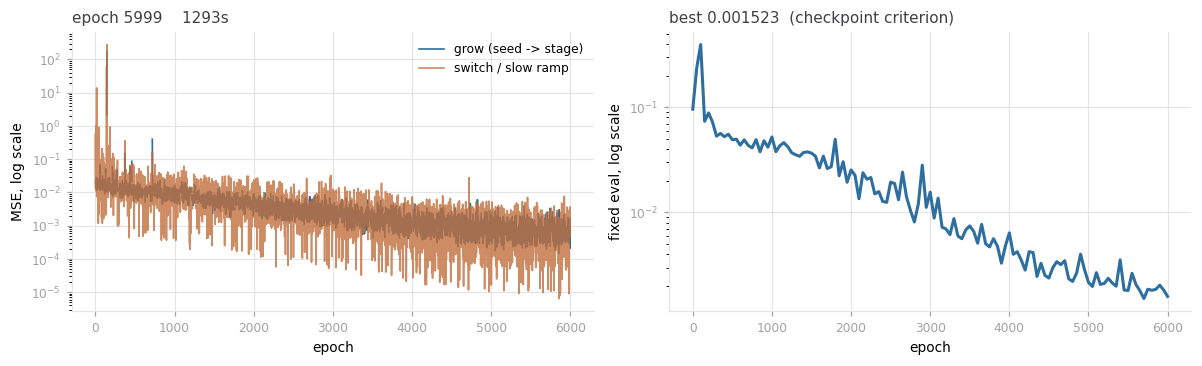

done in 1293.6s | best fixed-eval 0.001523 | weights restored to best
saved outputs\env_growth.pth


In [9]:
TRAIN = True    ## set False to load outputs/env_growth.pth instead of training (~20 min)
CKPT = os.path.join(CFG.out_dir, CFG.ckpt_name)

if TRAIN:
    history, evals = train(model, TARGETS, ENVS, CFG)
    save_checkpoint(model, NAMES, ENVS, CFG, CKPT)
else:
    model, NAMES, ENVS, CFG = load_checkpoint(CKPT)
    TARGETS, _, _ = plant_targets(CFG)
    TARGETS = TARGETS.to(DEVICE)
    K = TARGETS.shape[0]
    print(f"loaded {CKPT}")

## Verification — the acceptance tests

Six programmatic tests. The env-shuffle ablation is the manifold's shuffle-z test
applied to the environment: growing each stage under the *wrong* nutrient must be much
worse, or the environment is decoration. The last two run the actual time-varying
simulations and require clean endpoints — the ghost-alpha bound on `rise_fall` exists
because a stable wisp of dead flower once passed the MSE bar.

In [10]:
def verify(model, targets, envs, names, cfg=CFG):
    dev = targets.device
    results = {}

    ## 1. frozen without chemical: EXACTLY zero change over 50 steps
    grown = grow(model, envs[-1:], cfg.seg1_max, seed=1)
    chem0 = torch.zeros(1, 1, cfg.grid, cfg.grid, device=dev)
    frozen = grown
    for _ in range(50):
        frozen = model(frozen, model.weights_for(envs[-1:]), chem0)
    d = (frozen - grown).abs().max().item()
    results["freeze"] = (d == 0.0, f"max|delta| over 50 chem=0 steps = {d}")

    ## 2. per-stage growth from seed
    final = grow(model, envs, cfg.seg1_max, seed=2)
    per = (final[:, 0:4] - targets).pow(2).mean(dim=(1, 2, 3))
    worst = per.max().item()
    detail = ", ".join(f"{n} {v:.5f}" for n, v in zip(names, per.tolist()))
    results["stages"] = (worst < 0.005, f"per-stage MSE [{detail}], worst {worst:.5f} (< 0.005)")

    ## 3. env-shuffle ablation: the wrong nutrient must be much worse
    shuf = grow(model, envs.roll(1), cfg.seg1_max, seed=2)
    mse_ok = F.mse_loss(final[:, 0:4], targets).item()
    mse_sh = F.mse_loss(shuf[:, 0:4], targets).item()
    ratio = mse_sh / max(mse_ok, 1e-12)
    results["ablation"] = (ratio >= 10, f"correct {mse_ok:.6f} -> shuffled {mse_sh:.6f} "
                                        f"({ratio:.0f}x worse, need >= 10x)")

    ## 4. environment change: flower regresses to sprout when nutrient drops
    flower = grow(model, envs[-1:], cfg.seg1_max, seed=3)
    back = grow(model, envs[1:2], cfg.seg2_max + 16, state=flower, seed=4)
    mse_back = F.mse_loss(back[:, 0:4], targets[1:2]).item()
    results["regression"] = (mse_back < 0.01, f"flower -> n={envs[1]:.2f} -> sprout "
                                              f"MSE {mse_back:.5f} (< 0.01)")

    ## 5. continuous ramp: nutrient 0.1 -> 1.0 changing EVERY step for 480 steps
    total = 480
    ramp = lambda t: min(1.0, 0.10 + 0.90 * t / (total * 0.85))
    end, _, _ = simulate(model, ramp, total, seed=5)
    mse_ramp = F.mse_loss(end[:, 0:4], targets[-1:]).item()
    results["ramp"] = (mse_ramp < 0.01, f"continuous 480-step ramp -> flower "
                                        f"MSE {mse_ramp:.5f} (< 0.01)")

    ## 6. rise then fall: grow the flower, then ramp nutrient down to sprout
    def updown(t):
        if t < 160:
            return 1.00
        if t < 200:
            return round(1.0 - 0.6 * (t - 160) / 40, 3)
        return 0.40
    end, _, _ = simulate(model, updown, 420, seed=8)
    mse_ud = F.mse_loss(end[:, 0:4], targets[1:2]).item()
    ghost = end[0, 3].clamp(0, 1)[:18].sum().item()
    results["rise_fall"] = (mse_ud < 0.01 and ghost < 8.0,
                            f"flower then graded drop to n=0.40 -> sprout "
                            f"MSE {mse_ud:.5f} (< 0.01), ghost alpha {ghost:.1f} (< 8)")

    print("=== verification ===")
    ok = True
    for name, (passed, msg) in results.items():
        print(f"  [{'PASS' if passed else 'FAIL'}] {name:<11} {msg}")
        ok &= passed
    print(f"=== {'ALL PASSED' if ok else 'FAILURES PRESENT'} ===")
    return ok, results


VERIFY_OK, _ = verify(model, TARGETS, ENVS, NAMES, CFG)

=== verification ===
  [PASS] freeze      max|delta| over 50 chem=0 steps = 0.0
  [PASS] stages      per-stage MSE [seed 0.00001, sprout 0.00006, leafy 0.00011, flower 0.00183], worst 0.00183 (< 0.005)
  [PASS] ablation    correct 0.000502 -> shuffled 0.025503 (51x worse, need >= 10x)
  [PASS] regression  flower -> n=0.40 -> sprout MSE 0.00015 (< 0.01)
  [PASS] ramp        continuous 480-step ramp -> flower MSE 0.00126 (< 0.01)
  [PASS] rise_fall   flower then graded drop to n=0.40 -> sprout MSE 0.00023 (< 0.01), ghost alpha 0.3 (< 8)
=== ALL PASSED ===


## Figures and simulations

| output | question it answers |
|---|---|
| stages figure | Does the environment alone decide what grows? |
| nutrient ramp GIF | Does a *continuously changing* environment drive clean development? |
| chem gate GIF | Is the chemical necessary, not decorative? |
| chem half figure | Does a *spatial* chemical field confine growth in space? |
| nutrient collapse GIF | Does the organism regress when the environment degrades? |

saved outputs\env_stages.png


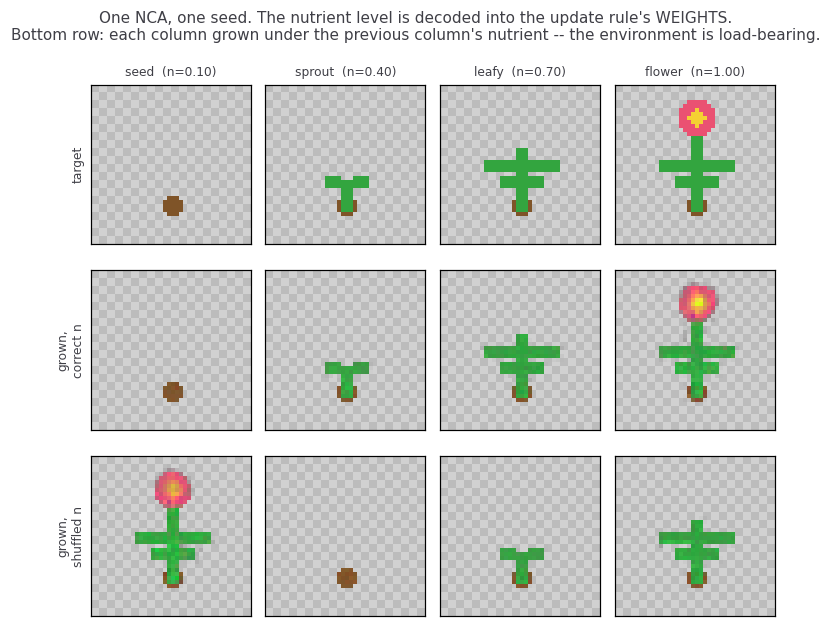

In [11]:
## stages: targets vs grown at the correct nutrient vs grown at the WRONG nutrient
final = grow(model, ENVS, CFG.seg1_max, seed=2)
shuf = grow(model, ENVS.roll(1), CFG.seg1_max, seed=2)
tile_figure([TARGETS[i] for i in range(K)]
            + [final[i] for i in range(K)]
            + [shuf[i] for i in range(K)],
            ncols=K,
            titles=[f"{n}  (n={e:.2f})" for n, e in zip(NAMES, ENVS.tolist())] + [""] * (2 * K),
            row_labels=["target", "grown,\ncorrect n", "grown,\nshuffled n"],
            suptitle="One NCA, one seed. The nutrient level is decoded into the update rule's WEIGHTS.\n"
                     "Bottom row: each column grown under the previous column's nutrient -- "
                     "the environment is load-bearing.",
            path=os.path.join(CFG.out_dir, "env_stages.png"));

end MSE vs flower target: 0.00126


saved outputs\env_ramp.gif (121 frames)


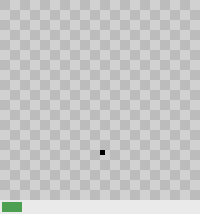

saved outputs\env_ramp_strip.png


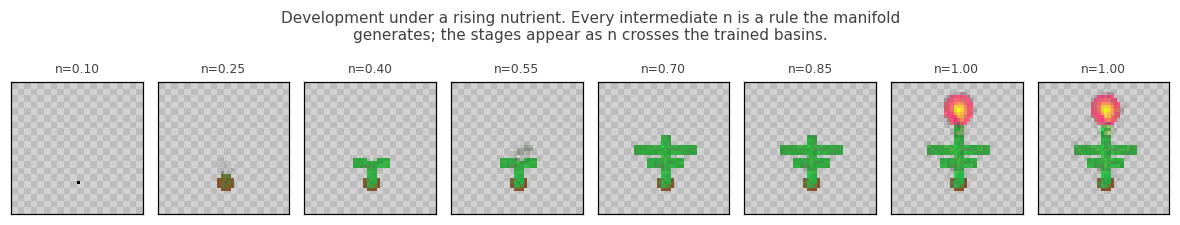

In [12]:
## nutrient ramp: n rises 0.1 -> 1.0 continuously (changing EVERY step) over 480 steps
TOTAL = 480
ramp = lambda t: min(1.0, 0.10 + 0.90 * t / (TOTAL * 0.85))
end, frames, trace = simulate(model, ramp, TOTAL, record_every=4, seed=5)
print(f"end MSE vs flower target: {F.mse_loss(end[:, 0:4], TARGETS[-1:]).item():.5f}")

gif = [frame_with_bar(upscale(composite(f[0]), 5), n, "nutrient")
       for f, n in zip(frames, trace)]
path = save_gif(gif, os.path.join(CFG.out_dir, "env_ramp.gif"))
display(IPyImage(filename=path))

idx = np.linspace(0, len(frames) - 1, 8).astype(int)
tile_figure([frames[i][0] for i in idx], ncols=8,
            titles=[f"n={trace[i]:.2f}" for i in idx], scale=4, tile_in=1.35,
            suptitle="Development under a rising nutrient. Every intermediate n is a rule the manifold\n"
                     "generates; the stages appear as n crosses the trained basins.",
            path=os.path.join(CFG.out_dir, "env_ramp_strip.png"));

saved outputs\env_chem_gate.gif (91 frames)


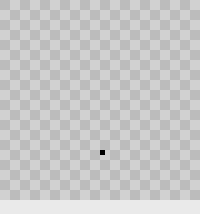

In [13]:
## chemical gate in TIME: no chemical until step 120 -- the seed sits exactly frozen
ONSET = 120
g = CFG.grid
chem_t = lambda t: torch.full((1, 1, g, g), 0.0 if t < ONSET else 1.0, device=DEVICE)
_, frames, _ = simulate(model, lambda t: 1.0, 360, chem_fn=chem_t, record_every=4, seed=6)
gif = [frame_with_bar(upscale(composite(f[0], chem_t(i * 4)[0, 0]), 5),
                      0.0 if i * 4 < ONSET else 1.0, "chem")
       for i, f in enumerate(frames)]
path = save_gif(gif, os.path.join(CFG.out_dir, "env_chem_gate.gif"))
display(IPyImage(filename=path))

saved outputs\env_chem_half.png


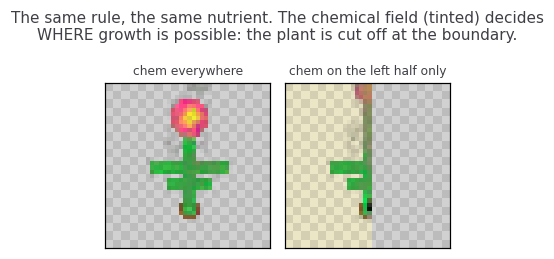

In [14]:
## chemical gate in SPACE: chemical only on the left half -- growth cannot cross it
half = torch.zeros(1, 1, CFG.grid, CFG.grid, device=DEVICE)
half[..., : CFG.grid // 2 + 1] = 1.0
grown_full = grow(model, ENVS[-1:], CFG.seg1_max * 2, seed=7)
grown_half = grow(model, ENVS[-1:], CFG.seg1_max * 2, chem=half, seed=7)
tile_figure([grown_full[0], grown_half[0]], ncols=2,
            titles=["chem everywhere", "chem on the left half only"],
            chems=[None, half[0, 0]],
            suptitle="The same rule, the same nutrient. The chemical field (tinted) decides\n"
                     "WHERE growth is possible: the plant is cut off at the boundary.",
            path=os.path.join(CFG.out_dir, "env_chem_half.png"));

end MSE vs sprout target: 0.00023


saved outputs\env_regress.gif (106 frames)


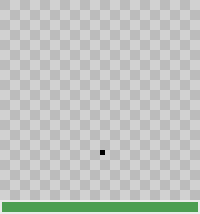

In [15]:
## nutrient collapse: full flower, then the nutrient falls to 0.40 -- the organism
## regresses to the sprout form
def updown(t):
    if t < 160:
        return 1.00
    if t < 200:
        return round(1.0 - 0.6 * (t - 160) / 40, 3)
    return 0.40

end, frames, trace = simulate(model, updown, 420, record_every=4, seed=8)
print(f"end MSE vs sprout target: {F.mse_loss(end[:, 0:4], TARGETS[1:2]).item():.5f}")
gif = [frame_with_bar(upscale(composite(f[0]), 5), n, "nutrient")
       for f, n in zip(frames, trace)]
path = save_gif(gif, os.path.join(CFG.out_dir, "env_regress.gif"))
display(IPyImage(filename=path))

## Recipe: adapt this to your own organism

1. **Edit `plant_targets`** — any list of nested (or not) RGBA stages with a nutrient
   level each. Keep the anchor point under the seed cell (`new_seed` plants it at
   row 30, centre column).
2. **Keep the jitter partition invariant.** If you move the stage levels, set
   `env_jitter` so the basins `level_i ± jitter` tile $[0,1]$ without gaps. A slow ramp
   will visit *every* nutrient value; untrained gaps grow artefacts (duplicate organs).
3. Run the sanity cell, then train. Watch the **right-hand plot** (the fixed eval) —
   that is what selects the checkpoint; the training losses jump between episode types
   by design.
4. The six verification tests are the result. `freeze` and `ablation` are the two that
   tell you the external signals are load-bearing rather than decoration.

### When it does not work

| symptom | cause | fix |
|---|---|---|
| ablation ratio near 1 | environments all decode to the same rule | raise `latent_dim` / `dna_hidden`; train longer |
| duplicate organs during a slow ramp | untrained nutrient gap between basins | fix the `env_jitter` partition (lesson 2) |
| ghost residue after the env falls | descending transitions under-trained | keep `slow_ramp_prob` at 0.33 -- both ramp directions are sampled |
| ramp fails but instant switches pass | slow-dwell states out of distribution | that is what `_slow_ramp_episode` exists for; do not remove it |
| stages fine but blurry | too many stages for the capacity | raise `hidden`, or fewer stages |

### What this does not do

The chemical field is **exogenous** — set by the simulation, not produced or consumed
by cells. Chemical consumption/diffusion, division mechanics and WebGPU export remain
out of scope, as in the design doc.